# Option Pricing & Greeks

This notebook explores Black-Scholes option pricing and the Greeks — the sensitivities that describe how an option's value responds to changes in market conditions.

| Greek | Symbol | Measures sensitivity to... |
|---|---|---|
| **Delta** | Δ | Stock price S |
| **Gamma** | Γ | Rate of change of Delta (curvature in S) |
| **Vega** | ν | Volatility σ |
| **Theta** | Θ | Time to expiration T (time decay) |

We visualize each greek both as a **2D curve** (intuition) and a **3D surface** (full parameter space).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import norm
import sys
from pathlib import Path

# Notebook lives at src/option_pricing/greeks.ipynb
# In Jupyter, __file__ doesn't exist — use Path().resolve() instead
THIS_DIR = Path().resolve()
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

from black_scholes import (
    call_price, put_price,
    delta_call, delta_put,
    gamma, vega, theta_call,
    _d1, _d2,
    put_call_parity_check,
)

print('Imports OK')

Imports OK


---
## 1. Shared Parameters & Setup

In [2]:
# ---- Base parameters ----
K     = 100      # strike price
r     = 0.05     # risk-free rate
T     = 1.0      # time to expiration (years)
sigma = 0.2      # volatility

# ---- Grids ----
S_vals     = np.linspace(50, 150, 200)       # spot price range
sigma_vals = np.linspace(0.05, 0.6, 60)      # vol range
S_grid, sigma_grid = np.meshgrid(
    np.linspace(50, 150, 60),
    np.linspace(0.05, 0.6, 60)
)

# ---- Verify put-call parity ----
put_call_parity_check(S=100, K=K, T=T, r=r, sigma=sigma)

Put-Call Parity Check:
  C - P = 4.877058
  S - K*e^(-rT) = 4.877058
  Difference: 0.00e+00  ✓ PASS


---
## 2. Option Price vs Spot Price

Before looking at Greeks, let's see how call and put prices behave as the stock price moves.

- **Call** value increases as S rises (you want the stock high)
- **Put** value increases as S falls (you want the stock low)
- Both converge to their **intrinsic value** as volatility → 0 or T → 0

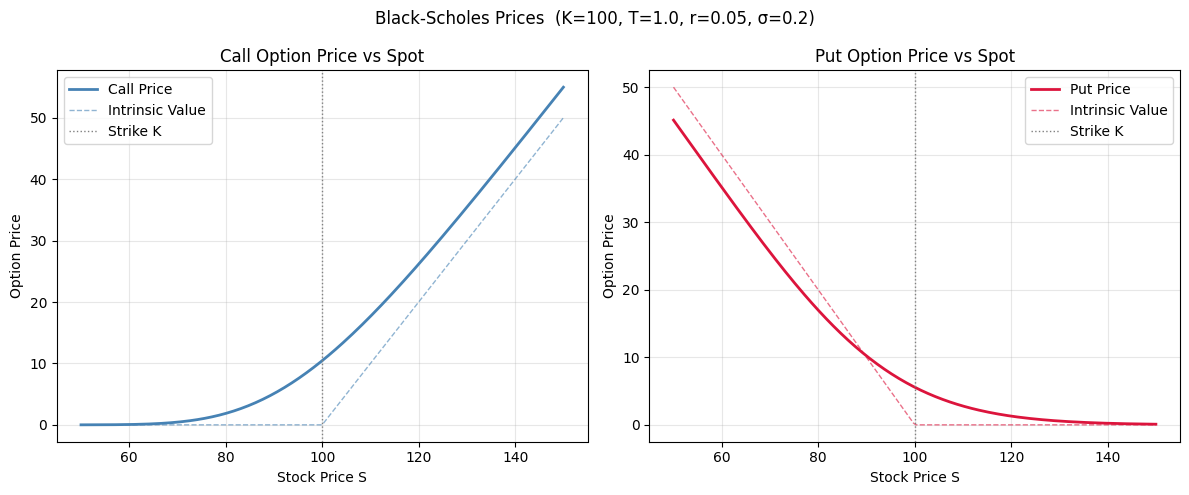

In [3]:
calls = call_price(S_vals, K, T, r, sigma)
puts  = put_price(S_vals, K, T, r, sigma)
intrinsic_call = np.maximum(S_vals - K, 0)
intrinsic_put  = np.maximum(K - S_vals, 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(S_vals, calls, color='steelblue', linewidth=2, label='Call Price')
axes[0].plot(S_vals, intrinsic_call, color='steelblue', linewidth=1,
             linestyle='--', alpha=0.6, label='Intrinsic Value')
axes[0].axvline(K, color='gray', linestyle=':', linewidth=1, label='Strike K')
axes[0].set_title('Call Option Price vs Spot')
axes[0].set_xlabel('Stock Price S')
axes[0].set_ylabel('Option Price')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(S_vals, puts, color='crimson', linewidth=2, label='Put Price')
axes[1].plot(S_vals, intrinsic_put, color='crimson', linewidth=1,
             linestyle='--', alpha=0.6, label='Intrinsic Value')
axes[1].axvline(K, color='gray', linestyle=':', linewidth=1, label='Strike K')
axes[1].set_title('Put Option Price vs Spot')
axes[1].set_xlabel('Stock Price S')
axes[1].set_ylabel('Option Price')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Black-Scholes Prices  (K={K}, T={T}, r={r}, σ={sigma})', fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Call Price Surface

The 3D surface shows call price as a function of both **S** and **σ**.
Higher volatility always increases option value — more uncertainty = more chance of a big favorable move.

In [4]:
V = call_price(S_grid, K, T, r, sigma_grid)

fig = go.Figure(data=[go.Surface(
    x=S_grid, y=sigma_grid, z=V,
    colorscale='Viridis', opacity=0.9
)])
fig.update_layout(
    title='Black-Scholes Call Price Surface',
    scene=dict(
        xaxis_title='Stock Price (S)',
        yaxis_title='Volatility (σ)',
        zaxis_title='Call Price',
    )
)
fig.show()

---
## 4. Delta (Δ) — Sensitivity to Stock Price

$$\Delta_{call} = N(d_1) \qquad \Delta_{put} = N(d_1) - 1$$

- Call Delta ∈ [0, 1]: deep ITM → Δ ≈ 1, deep OTM → Δ ≈ 0
- Put Delta ∈ [-1, 0]: deep ITM → Δ ≈ -1, deep OTM → Δ ≈ 0
- At-the-money: call Δ ≈ 0.5, put Δ ≈ -0.5

**Trading intuition:** Delta is the hedge ratio — to delta-hedge a short call, buy Δ shares of stock.

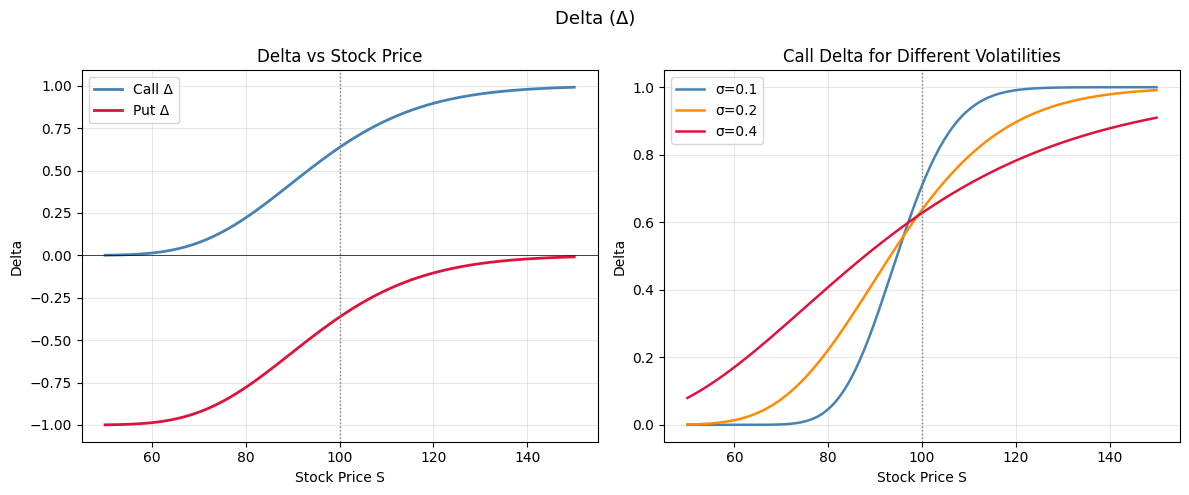

In [5]:
# ---- 2D: Delta vs spot ----
d_call = delta_call(S_vals, K, T, r, sigma)
d_put  = delta_put(S_vals, K, T, r, sigma)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(S_vals, d_call, color='steelblue', linewidth=2, label='Call Δ')
axes[0].plot(S_vals, d_put,  color='crimson',   linewidth=2, label='Put Δ')
axes[0].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Delta vs Stock Price')
axes[0].set_xlabel('Stock Price S')
axes[0].set_ylabel('Delta')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Delta sensitivity to sigma
for sig, color in zip([0.1, 0.2, 0.4], ['steelblue', 'darkorange', 'crimson']):
    axes[1].plot(S_vals, delta_call(S_vals, K, T, r, sig),
                 color=color, linewidth=1.8, label=f'σ={sig}')
axes[1].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Call Delta for Different Volatilities')
axes[1].set_xlabel('Stock Price S')
axes[1].set_ylabel('Delta')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Delta (Δ)', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# ---- 3D: Delta surface ----
Delta_surface = delta_call(S_grid, K, T, r, sigma_grid)

fig = go.Figure(data=[go.Surface(
    x=S_grid, y=sigma_grid, z=Delta_surface,
    colorscale='Blues', opacity=0.9
)])
fig.update_layout(
    title='Delta Surface (∂C / ∂S)',
    scene=dict(
        xaxis_title='Stock Price (S)',
        yaxis_title='Volatility (σ)',
        zaxis_title='Delta',
    )
)
fig.show()

---
## 5. Gamma (Γ) — Rate of Change of Delta

$$\Gamma = \frac{N'(d_1)}{S \sigma \sqrt{T}}$$

- Gamma is always positive for both calls and puts
- Peaks at-the-money — Delta changes fastest here
- High Gamma means your hedge ratio changes rapidly as the stock moves

**Trading intuition:** High Gamma = your delta hedge needs frequent rebalancing.

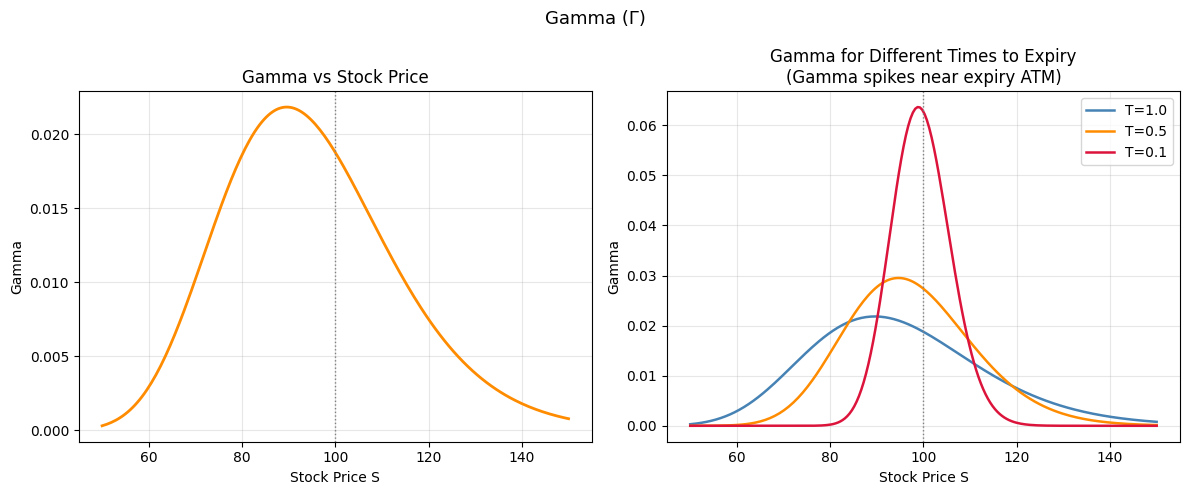

In [7]:
g = gamma(S_vals, K, T, r, sigma)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(S_vals, g, color='darkorange', linewidth=2)
axes[0].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[0].set_title('Gamma vs Stock Price')
axes[0].set_xlabel('Stock Price S')
axes[0].set_ylabel('Gamma')
axes[0].grid(alpha=0.3)

# Gamma sensitivity to time
for T_val, color in zip([1.0, 0.5, 0.1], ['steelblue', 'darkorange', 'crimson']):
    axes[1].plot(S_vals, gamma(S_vals, K, T_val, r, sigma),
                 color=color, linewidth=1.8, label=f'T={T_val}')
axes[1].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Gamma for Different Times to Expiry\n(Gamma spikes near expiry ATM)')
axes[1].set_xlabel('Stock Price S')
axes[1].set_ylabel('Gamma')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Gamma (Γ)', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ---- 3D: Gamma surface ----
Gamma_surface = gamma(S_grid, K, T, r, sigma_grid)

fig = go.Figure(data=[go.Surface(
    x=S_grid, y=sigma_grid, z=Gamma_surface,
    colorscale='Oranges', opacity=0.9
)])
fig.update_layout(
    title='Gamma Surface (∂²C / ∂S²)',
    scene=dict(
        xaxis_title='Stock Price (S)',
        yaxis_title='Volatility (σ)',
        zaxis_title='Gamma',
    )
)
fig.show()

---
## 6. Vega (ν) — Sensitivity to Volatility

$$\text{Vega} = S \cdot N'(d_1) \cdot \sqrt{T}$$

- Always positive: higher vol always increases option value
- Peaks at-the-money (ATM options have the most to gain from vol increases)
- Larger for longer-dated options (more time for vol to matter)

**Trading intuition:** Long options = long vega. If you expect vol to rise, buy options.

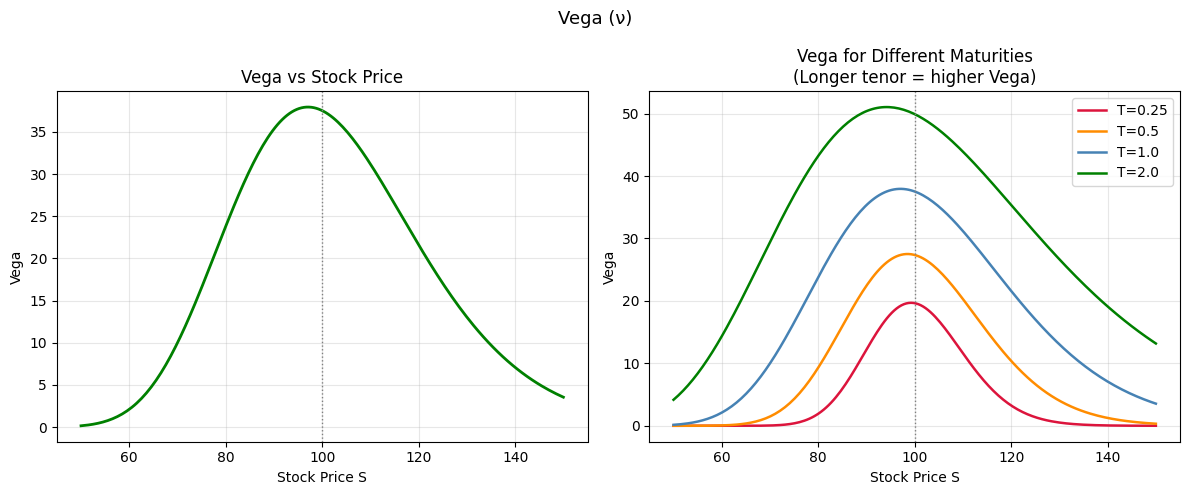

In [9]:
v = vega(S_vals, K, T, r, sigma)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(S_vals, v, color='green', linewidth=2)
axes[0].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[0].set_title('Vega vs Stock Price')
axes[0].set_xlabel('Stock Price S')
axes[0].set_ylabel('Vega')
axes[0].grid(alpha=0.3)

# Vega across different maturities
for T_val, color in zip([0.25, 0.5, 1.0, 2.0], ['crimson', 'darkorange', 'steelblue', 'green']):
    axes[1].plot(S_vals, vega(S_vals, K, T_val, r, sigma),
                 color=color, linewidth=1.8, label=f'T={T_val}')
axes[1].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Vega for Different Maturities\n(Longer tenor = higher Vega)')
axes[1].set_xlabel('Stock Price S')
axes[1].set_ylabel('Vega')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Vega (ν)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# ---- 3D: Vega surface ----
Vega_surface = vega(S_grid, K, T, r, sigma_grid)

fig = go.Figure(data=[go.Surface(
    x=S_grid, y=sigma_grid, z=Vega_surface,
    colorscale='Greens', opacity=0.9
)])
fig.update_layout(
    title='Vega Surface (∂C / ∂σ)',
    scene=dict(
        xaxis_title='Stock Price (S)',
        yaxis_title='Volatility (σ)',
        zaxis_title='Vega',
    )
)
fig.show()

---
## 7. Theta (Θ) — Time Decay

$$\Theta = -\frac{S \cdot N'(d_1) \cdot \sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2)$$

- Always negative for long options (option loses value as time passes)
- Most negative at-the-money — that's where time value is highest
- **Accelerates near expiration**: an ATM option loses value faster in its last week than in its first month

**Trading intuition:** Long options = short theta. You pay time decay every day you hold.

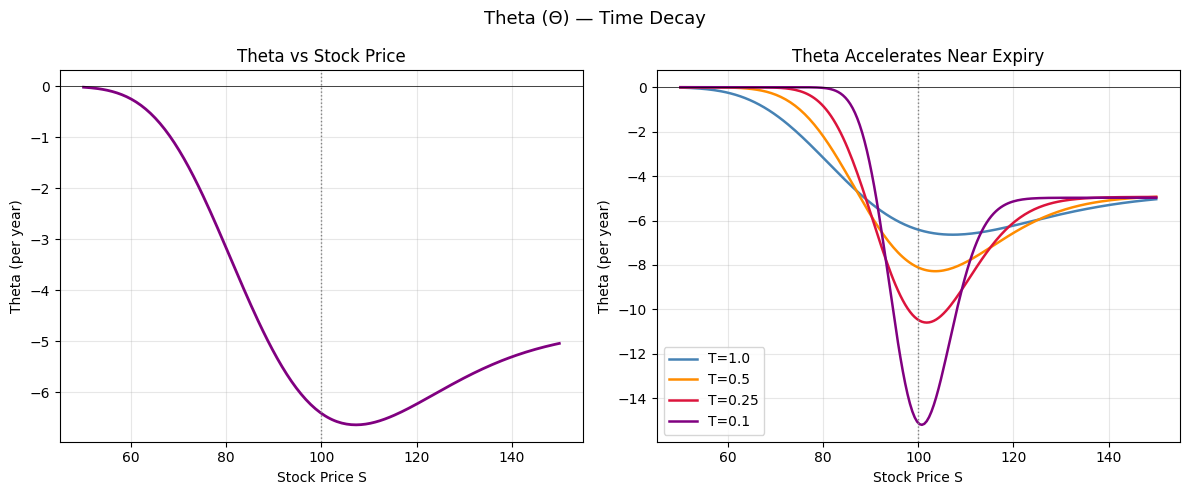

In [11]:
th = theta_call(S_vals, K, T, r, sigma)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(S_vals, th, color='purple', linewidth=2)
axes[0].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Theta vs Stock Price')
axes[0].set_xlabel('Stock Price S')
axes[0].set_ylabel('Theta (per year)')
axes[0].grid(alpha=0.3)

# Theta accelerates near expiry
for T_val, color in zip([1.0, 0.5, 0.25, 0.1], ['steelblue', 'darkorange', 'crimson', 'purple']):
    axes[1].plot(S_vals, theta_call(S_vals, K, T_val, r, sigma),
                 color=color, linewidth=1.8, label=f'T={T_val}')
axes[1].axvline(K, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Theta Accelerates Near Expiry')
axes[1].set_xlabel('Stock Price S')
axes[1].set_ylabel('Theta (per year)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Theta (Θ) — Time Decay', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# ---- 3D: Theta surface ----
Theta_surface = theta_call(S_grid, K, T, r, sigma_grid)

fig = go.Figure(data=[go.Surface(
    x=S_grid, y=sigma_grid, z=Theta_surface,
    colorscale='Purples', opacity=0.9
)])
fig.update_layout(
    title='Theta Surface (∂C / ∂T)',
    scene=dict(
        xaxis_title='Stock Price (S)',
        yaxis_title='Volatility (σ)',
        zaxis_title='Theta',
    )
)
fig.show()

---
## 8. All Greeks Together

Side-by-side overview of all four Greeks at ATM (S=K=100).

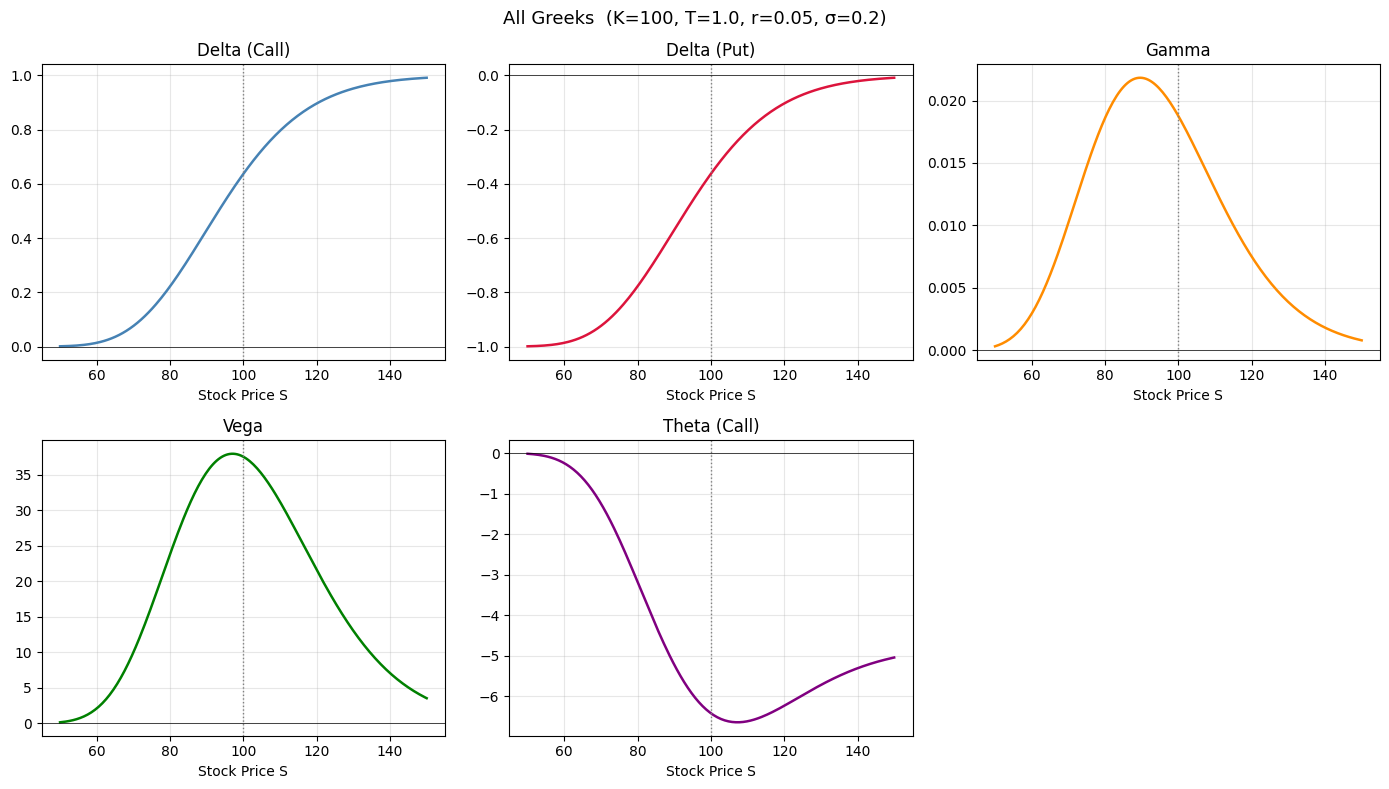

In [13]:
greeks_data = {
    'Delta (Call)':  (delta_call(S_vals, K, T, r, sigma), 'steelblue'),
    'Delta (Put)':   (delta_put(S_vals, K, T, r, sigma),  'crimson'),
    'Gamma':         (gamma(S_vals, K, T, r, sigma),       'darkorange'),
    'Vega':          (vega(S_vals, K, T, r, sigma),        'green'),
    'Theta (Call)':  (theta_call(S_vals, K, T, r, sigma),  'purple'),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (label, (values, color)) in zip(axes, greeks_data.items()):
    ax.plot(S_vals, values, color=color, linewidth=1.8)
    ax.axvline(K, color='gray', linestyle=':', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel('Stock Price S')
    ax.grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle(f'All Greeks  (K={K}, T={T}, r={r}, σ={sigma})', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Summary

| Greek | Sign | Peaks at | Key Insight |
|---|---|---|---|
| **Delta** | + (call), − (put) | Deep ITM | Hedge ratio; converges to 0 or ±1 at extremes |
| **Gamma** | Always + | ATM | Delta changes fastest here; spikes near expiry |
| **Vega** | Always + | ATM | Long options are always long vol |
| **Theta** | Always − | ATM | Time decay accelerates as expiry approaches |

**Next:** The `monte_carlo_pricing` notebook shows how to price options numerically via simulation — validating these closed-form results and extending to cases where no formula exists.